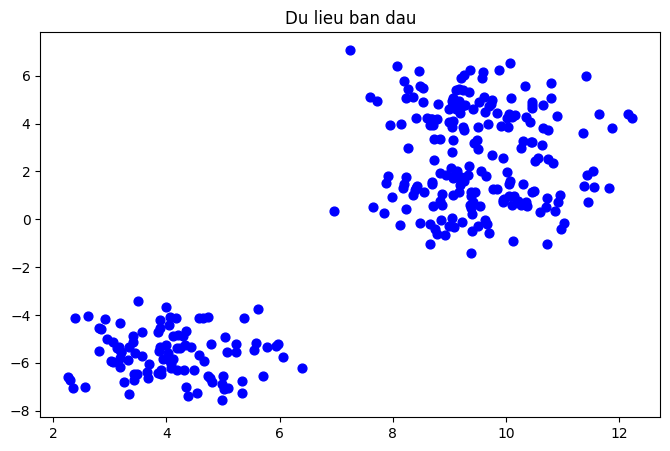

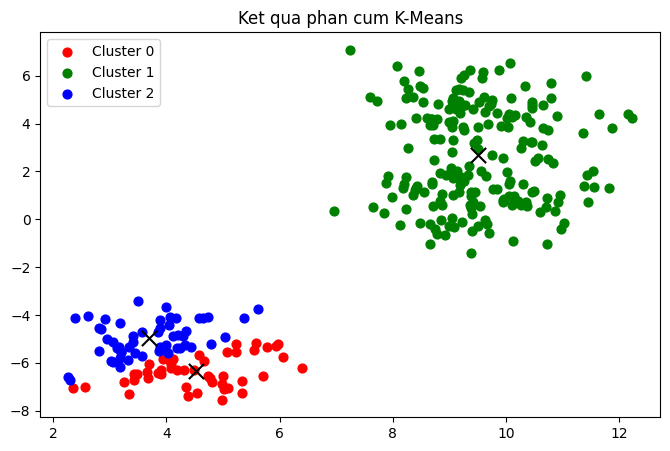

In [ ]:
# BTVN Bài 1

# K-Means

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.spatial.distance import cdist

X, y = make_blobs(
    n_samples = 300,
    n_features = 2,
    centers = 3,
    cluster_std = 1,
    random_state = 4
)

plt.figure(figsize = (8,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c = 'blue',
    s = 40
)

plt.title("Du lieu ban dau")

plt.show()

def createCenter(X, k):

    index = np.random.choice(
        X.shape[0],
        k,
        replace = False
    )

    return X[index]

def predictLabel(X, centers):

    D = cdist(X, centers)

    return np.argmin(D, axis = 1)

def updateCenter(X, labels, k):

    centers = np.zeros((k, X.shape[1]))

    for i in range(k):

        data = X[labels == i]

        centers[i] = np.mean(data, axis = 0)

    return centers

def checkConverged(oldCenters, newCenters):

    return (
        set([tuple(x) for x in oldCenters]) ==
        set([tuple(x) for x in newCenters])
    )

def Kmeans(X, k):

    centers = createCenter(X, k)

    while True:

        labels = predictLabel(X, centers)

        newCenters = updateCenter(X, labels, k)

        if checkConverged(centers, newCenters):
            break

        centers = newCenters

    return centers, labels

centers, labels = Kmeans(X, 3)

plt.figure(figsize = (8,5))

colors = ['red', 'green', 'blue']

for i in range(3):

    data = X[labels == i]

    plt.scatter(
        data[:,0],
        data[:,1],
        c = colors[i],
        s = 40,
        label = 'Cluster ' + str(i)
    )

    plt.scatter(
        centers[i][0],
        centers[i][1],
        c = 'black',
        s = 120,
        marker = 'x'
    )

plt.title("Ket qua phan cum K-Means")

plt.legend()

plt.show()


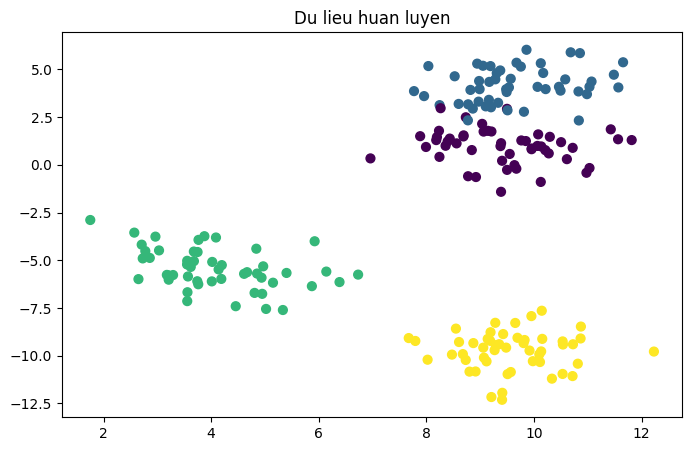

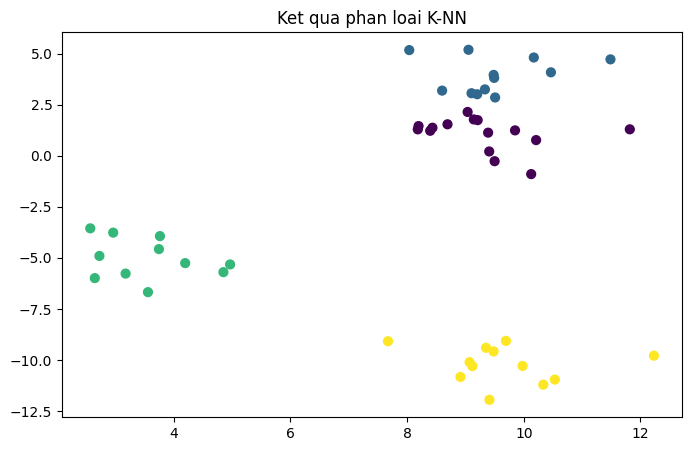

Diem moi: [[1 3]]
Du doan thuoc lop: [0]


In [ ]:
# BTVN Bài 1

# K-NN

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X, y = make_blobs(
    n_samples = 200,
    n_features = 2,
    centers = 4,
    cluster_std = 1,
    random_state = 4
)

plt.figure(figsize = (8,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c = y,
    s = 40
)

plt.title("Du lieu huan luyen")

plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state = 0
)

model = KNeighborsClassifier(n_neighbors = 3)

model.fit(X_train, y_train)

predict = model.predict(X_test)

plt.figure(figsize = (8,5))

plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c = predict,
    s = 40
)

plt.title("Ket qua phan loai K-NN")

plt.show()

new_point = np.array([[1,3]])

result = model.predict(new_point)

print("Diem moi:", new_point)

print("Du doan thuoc lop:", result)


In [ ]:
# BTVN Bài 2 - AKT

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['G'],
    'F': [],
    'G': []
}

open_list = ['A']

closed_list = []

parent = {}

found = False

while len(open_list) > 0:

    node = open_list.pop(0)

    closed_list.append(node)

    if node == 'G':

        found = True

        break

    for child in graph[node]:

        if child not in open_list and child not in closed_list:

            open_list.append(child)

            parent[child] = node

path = []

if found:

    node = 'G'

    while node != 'A':

        path.append(node)

        node = parent[node]

    path.append('A')

    path.reverse()

    print("Duong di tim duoc:")

    print(path)

else:

    print("Khong tim thay duong di")


Duong di tim duoc:
['A', 'B', 'E', 'G']


In [ ]:
# BTVN Bài 2 - A*

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['G'],
    'F': [],
    'G': []
}

open_list = ['A']

closed_list = []

parent = {}

found = False

while len(open_list) > 0:

    node = open_list.pop(0)

    closed_list.append(node)

    if node == 'G':

        found = True

        break

    for child in graph[node]:

        if child not in open_list and child not in closed_list:

            open_list.append(child)

            parent[child] = node

path = []

if found:

    node = 'G'

    while node != 'A':

        path.append(node)

        node = parent[node]

    path.append('A')

    path.reverse()

    print("Duong di tim duoc:")

    print(path)

else:

    print("Khong tim thay duong di")


Duong di tim duoc:
['A', 'B', 'E', 'G']


In [ ]:
# BTVN Bài 2 - Minimax

tree = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G']
}

value = {
    'D': 3,
    'E': 5,
    'F': 2,
    'G': 9
}

def minimax(node, isMax):

    if node in value:
        return value[node]

    if isMax:

        best = -1000

        for child in tree[node]:

            best = max(
                best,
                minimax(child, False)
            )

        return best

    else:

        best = 1000

        for child in tree[node]:

            best = min(
                best,
                minimax(child, True)
            )

        return best

result = minimax('A', True)

print("Gia tri tot nhat:", result)


Gia tri tot nhat: 3


In [ ]:
# BTVN Bài 2 - Alpha-Beta

tree = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G']
}

value = {
    'D': 3,
    'E': 5,
    'F': 2,
    'G': 9
}

def alphaBeta(node, depth, alpha, beta, isMax):

    if node in value:
        return value[node]

    if isMax:

        best = -1000

        for child in tree[node]:

            val = alphaBeta(
                child,
                depth + 1,
                alpha,
                beta,
                False
            )

            best = max(best, val)

            alpha = max(alpha, best)

            if beta <= alpha:
                break

        return best

    else:

        best = 1000

        for child in tree[node]:

            val = alphaBeta(
                child,
                depth + 1,
                alpha,
                beta,
                True
            )

            best = min(best, val)

            beta = min(beta, best)

            if beta <= alpha:
                break

        return best

result = alphaBeta(
    'A',
    0,
    -1000,
    1000,
    True
)

print("Ket qua Alpha-Beta:")

print(result)


Ket qua Alpha-Beta:
3


In [ ]:
# BTVN Bài 2 - Graph Coloring Algorithm

G = [
    [0,1,1,0],
    [1,0,1,1],
    [1,1,0,1],
    [0,1,1,0]
]

node = "ABCD"

color = {}

availableColor = [
    "Red",
    "Blue",
    "Green",
    "Yellow"
]

for i in range(len(node)):

    used = []

    for j in range(len(node)):

        if G[i][j] == 1:

            if node[j] in color:
                used.append(color[node[j]])

    for c in availableColor:

        if c not in used:

            color[node[i]] = c

            break

print("Ket qua to mau:\n")

for n in color:

    print(n, "=", color[n])


Ket qua to mau:

A = Red
B = Blue
C = Green
D = Red
